In [1]:
import pandas as pd, glob

# Load one station, one product
files = glob.glob("../noaa_data_pipeline/data/coops/station=*/**/**/*.parquet", recursive=True)
df = pd.concat([pd.read_parquet(f) for f in sorted(files)])

print(df.shape)
print(df.isnull().sum())
print(df.describe())
df.head(30)

(64829253, 8)
timestamp              0
station_id             0
product                0
value           10537533
quality_flag    42536808
speed           37174089
dr              58131906
direction       59275800
dtype: int64
                           timestamp         value         speed     direction
count                       64829253  5.429172e+07  2.765516e+07  5.553453e+06
mean   2012-10-10 17:43:36.217700608  1.971984e+02  7.995371e-01  1.621911e+02
min              1996-01-01 00:00:00 -1.790000e+01 -9.999000e+01  0.000000e+00
25%              2005-10-11 06:18:00  1.084000e+00  9.000000e-03  4.600000e+01
50%              2013-05-22 17:36:00  5.300000e+00  1.700000e-02  1.770000e+02
75%              2019-08-15 19:30:00  2.270000e+01  6.800000e-02  2.540000e+02
max              2026-03-04 23:54:00  1.045700e+03  2.280000e+01  9.999000e+03
std                              NaN  3.948667e+02  1.966652e+00  1.335705e+02


,timestamp,station_id,product,value,quality_flag,speed,dr,direction
0,1998-10-01 00:00:00,8516945,air_pressure,NaN,NaN,NaN,NaN,NaN
1,1998-10-01 00:06:00,8516945,air_pressure,NaN,NaN,NaN,NaN,NaN
2,1998-10-01 00:12:00,8516945,air_pressure,NaN,NaN,NaN,NaN,NaN
3,1998-10-01 00:18:00,8516945,air_pressure,NaN,NaN,NaN,NaN,NaN
4,1998-10-01 00:24:00,8516945,air_pressure,NaN,NaN,NaN,NaN,NaN
5,1998-10-01 00:30:00,8516945,air_pressure,NaN,NaN,NaN,NaN,NaN
6,1998-10-01 00:36:00,8516945,air_pressure,NaN,NaN,NaN,NaN,NaN
7,1998-10-01 00:42:00,8516945,air_pressure,NaN,NaN,NaN,NaN,NaN
8,1998-10-01 00:48:00,8516945,air_pressure,NaN,NaN,NaN,NaN,NaN
9,1998-10-01 00:54:00,8516945,air_pressure,NaN,NaN,NaN,NaN,NaN


In [2]:
df_wide = df.pivot_table(index="timestamp", columns="product", values="value", aggfunc="first")
df_wide.columns.name = None
df_wide = df_wide.reset_index()
df_wide.head(30)


,timestamp,air_pressure,air_temperature,water_level,water_temperature
0,1996-01-01 00:00:00,NaN,NaN,0.843,NaN
1,1996-01-01 00:06:00,NaN,NaN,0.821,NaN
2,1996-01-01 00:12:00,NaN,NaN,0.796,NaN
3,1996-01-01 00:18:00,NaN,NaN,0.768,NaN
4,1996-01-01 00:24:00,NaN,NaN,0.736,NaN
5,1996-01-01 00:30:00,NaN,NaN,0.706,NaN
6,1996-01-01 00:36:00,NaN,NaN,0.678,NaN
7,1996-01-01 00:42:00,NaN,NaN,0.649,NaN
8,1996-01-01 00:48:00,NaN,NaN,0.617,NaN
9,1996-01-01 00:54:00,NaN,NaN,0.588,NaN


In [3]:
df_by_hour = df_wide[df_wide["timestamp"].dt.minute == 0]
df_by_hour.head(100)


,timestamp,air_pressure,air_temperature,water_level,water_temperature
0,1996-01-01 00:00:00,NaN,NaN,0.843,NaN
10,1996-01-01 01:00:00,NaN,NaN,0.558,NaN
20,1996-01-01 02:00:00,NaN,NaN,0.367,NaN
30,1996-01-01 03:00:00,NaN,NaN,0.223,NaN
40,1996-01-01 04:00:00,NaN,NaN,0.185,NaN
...,...,...,...,...,...
950,1996-01-04 23:00:00,NaN,NaN,1.217,NaN
960,1996-01-05 00:00:00,NaN,NaN,1.343,NaN
970,1996-01-05 01:00:00,NaN,NaN,1.352,NaN
980,1996-01-05 02:00:00,NaN,NaN,1.204,NaN


In [4]:
df_by_hour.isnull().sum()

timestamp                0
air_pressure         28649
air_temperature      41098
water_level              0
water_temperature    18642
dtype: int64

In [5]:
df_by_hour.describe()

,timestamp,air_pressure,air_temperature,water_level,water_temperature
count,264504,235855.000000,223406.000000,264504.000000,245862.000000
mean,2011-02-01 11:30:00,1016.648551,12.307901,1.220979,12.910190
min,1996-01-01 00:00:00,965.700000,-17.600000,-1.177000,-7.300000
25%,2003-07-18 05:45:00,1011.700000,4.900000,0.429000,5.600000
50%,2011-02-01 11:30:00,1016.600000,12.400000,1.185000,12.900000
75%,2018-08-18 17:15:00,1021.800000,20.400000,2.020000,20.200000
max,2026-03-04 23:00:00,1045.400000,37.100000,4.361000,44.700000
std,NaN,7.937854,9.258879,0.858978,7.801158


In [13]:
df_by_hour.tail(100)

,timestamp,air_pressure,air_temperature,water_level,water_temperature
264404,2026-02-28 20:00:00,1017.0,9.1,0.198,1.9
264405,2026-02-28 21:00:00,1016.8,8.5,0.115,1.6
264406,2026-02-28 22:00:00,1017.1,7.7,0.359,1.6
264407,2026-02-28 23:00:00,1017.5,7.8,1.119,1.7
264408,2026-03-01 00:00:00,1017.5,5.4,1.909,1.8
...,...,...,...,...,...
264499,2026-03-04 19:00:00,1024.3,5.8,1.802,2.2
264500,2026-03-04 20:00:00,1024.3,6.8,1.052,2.1
264501,2026-03-04 21:00:00,1024.3,9.7,0.402,2.1
264502,2026-03-04 22:00:00,1024.3,6.9,0.010,2.1


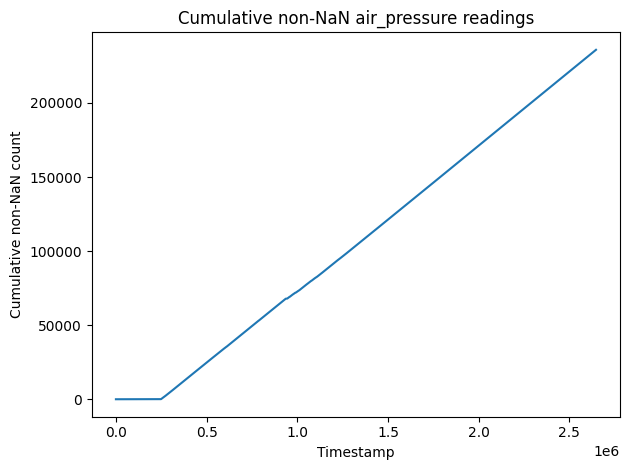

In [7]:
import matplotlib.pyplot as plt

ax = df_by_hour["air_pressure"].notna().cumsum().plot(title="Cumulative non-NaN air_pressure readings")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Cumulative non-NaN count")
plt.tight_layout()
plt.show()


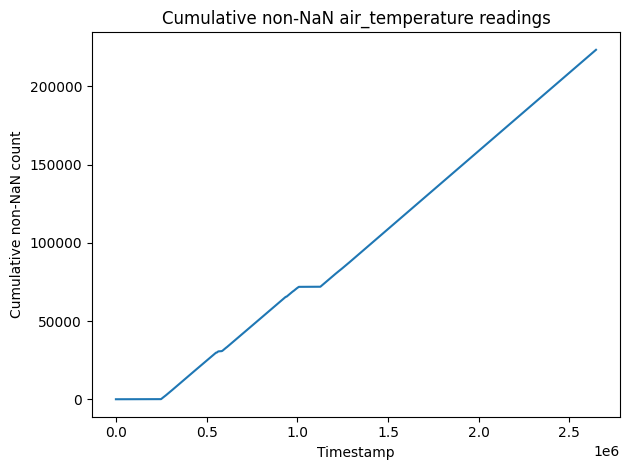

In [8]:
ax = df_by_hour["air_temperature"].notna().cumsum().plot(title="Cumulative non-NaN air_temperature readings")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Cumulative non-NaN count")
plt.tight_layout()
plt.show()


In [9]:
df_by_hour.iloc[[120000]]

,timestamp,air_pressure,air_temperature,water_level,water_temperature
1201966,2009-09-09,NaN,NaN,0.242,24.9


In [10]:
df_by_hour.iloc[[121631]]

,timestamp,air_pressure,air_temperature,water_level,water_temperature
1218276,2009-11-15 23:00:00,1012.4,15.6,0.135,14.9


In [11]:
df_by_hour.reset_index(drop=True, inplace=True)

In [12]:
print(df_by_hour["air_pressure"].first_valid_index())
print(df_by_hour["air_temperature"].first_valid_index())

24805
24805


In [14]:
df_by_hour = df_by_hour[['timestamp', 'water_level']]
df_by_hour.head(30)

,timestamp,water_level
0,1996-01-01 00:00:00,0.843
1,1996-01-01 01:00:00,0.558
2,1996-01-01 02:00:00,0.367
3,1996-01-01 03:00:00,0.223
4,1996-01-01 04:00:00,0.185
5,1996-01-01 05:00:00,0.439
6,1996-01-01 06:00:00,0.806
7,1996-01-01 07:00:00,1.163
8,1996-01-01 08:00:00,1.330
9,1996-01-01 09:00:00,1.413


In [15]:
df_by_hour.duplicated().sum()

0

In [18]:
df_by_hour = df_by_hour[df_by_hour["timestamp"].dt.year >= 2014]
df_by_hour = df_by_hour[df_by_hour["timestamp"].dt.month >= 2]
df_by_hour.head()

,timestamp,water_level
158544,2014-02-01 00:00:00,-0.572
158545,2014-02-01 01:00:00,0.023
158546,2014-02-01 02:00:00,1.245
158547,2014-02-01 03:00:00,2.182
158548,2014-02-01 04:00:00,2.384


In [19]:
df_ndbc = pd.read_csv('../data/processed/ndbc_data_with_astronomy.csv')
df_ndbc.head()

,timestamp,wind_speed_ms,wind_gust_ms,air_temp_c,water_temp_c,dewpoint_c,wind_direction_deg,air_pressure_hpa,sunrise_time,sunset_time,moonrise_time,moonset_time,moon_phase_age_days,sun_distance_km,moon_distance_km
0,2014-02-01 01:00:00,5.30,6.35,3.90,4.55,-1.9,281.0,1022.05,2014-01-31 07:06:39,2014-01-31 17:13:21,2014-01-31 07:14:00,2014-01-31 18:35:00,0.577889,1.474073e+08,361404.808532
1,2014-02-01 02:00:00,5.50,6.35,3.60,4.55,-4.4,283.0,1022.70,2014-01-31 07:06:39,2014-01-31 17:13:21,2014-01-31 07:14:00,2014-01-31 18:35:00,0.577889,1.474081e+08,362653.467797
2,2014-02-01 03:00:00,4.25,5.15,3.50,4.50,-4.7,269.5,1023.20,2014-01-31 07:06:39,2014-01-31 17:13:21,2014-01-31 07:14:00,2014-01-31 18:35:00,0.577889,1.474090e+08,363762.673757
3,2014-02-01 04:00:00,4.55,5.55,3.75,4.45,-5.1,279.5,1023.85,2014-01-31 07:06:39,2014-01-31 17:13:21,2014-01-31 07:14:00,2014-01-31 18:35:00,0.577889,1.474098e+08,364671.158659
4,2014-02-01 05:00:00,4.30,4.85,3.55,4.40,-5.1,262.0,1024.05,2014-02-01 07:05:43,2014-02-01 17:14:34,2014-02-01 07:54:00,NaN,1.666778,1.474107e+08,365330.514787


In [21]:
df_by_hour["timestamp"] = pd.to_datetime(df_by_hour["timestamp"], utc=True).dt.floor("h")
df_ndbc["timestamp"] = pd.to_datetime(df_ndbc["timestamp"], utc=True).dt.floor("h")

df_joined = df_by_hour.merge(
    df_ndbc,
    on="timestamp",
    how="left",
    suffixes=("_by_hour", "_ndbc"),
    indicator=True,
 )

df_joined["_merge"].map({"both": "matched", "left_only": "not_matched"}).value_counts()

_merge
matched        95614
not_matched     1418
Name: count, dtype: int64

In [22]:
df_joined.head(30)

,timestamp,water_level,wind_speed_ms,wind_gust_ms,air_temp_c,water_temp_c,dewpoint_c,wind_direction_deg,air_pressure_hpa,sunrise_time,sunset_time,moonrise_time,moonset_time,moon_phase_age_days,sun_distance_km,moon_distance_km,_merge
0,2014-02-01 00:00:00+00:00,-0.572,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
1,2014-02-01 01:00:00+00:00,0.023,5.30,6.35,3.90,4.55,-1.9,281.0,1022.05,2014-01-31 07:06:39,2014-01-31 17:13:21,2014-01-31 07:14:00,2014-01-31 18:35:00,0.577889,1.474073e+08,361404.808532,both
2,2014-02-01 02:00:00+00:00,1.245,5.50,6.35,3.60,4.55,-4.4,283.0,1022.70,2014-01-31 07:06:39,2014-01-31 17:13:21,2014-01-31 07:14:00,2014-01-31 18:35:00,0.577889,1.474081e+08,362653.467797,both
3,2014-02-01 03:00:00+00:00,2.182,4.25,5.15,3.50,4.50,-4.7,269.5,1023.20,2014-01-31 07:06:39,2014-01-31 17:13:21,2014-01-31 07:14:00,2014-01-31 18:35:00,0.577889,1.474090e+08,363762.673757,both
4,2014-02-01 04:00:00+00:00,2.384,4.55,5.55,3.75,4.45,-5.1,279.5,1023.85,2014-01-31 07:06:39,2014-01-31 17:13:21,2014-01-31 07:14:00,2014-01-31 18:35:00,0.577889,1.474098e+08,364671.158659,both
5,2014-02-01 05:00:00+00:00,2.370,4.30,4.85,3.55,4.40,-5.1,262.0,1024.05,2014-02-01 07:05:43,2014-02-01 17:14:34,2014-02-01 07:54:00,NaN,1.666778,1.474107e+08,365330.514787,both
6,2014-02-01 06:00:00+00:00,2.291,3.30,4.00,3.50,4.45,-4.6,277.5,1023.85,2014-02-01 07:05:43,2014-02-01 17:14:34,2014-02-01 07:54:00,NaN,1.666778,1.474116e+08,365707.925859,both
7,2014-02-01 07:00:00+00:00,1.856,3.45,4.05,3.45,4.35,-4.6,284.5,1024.10,2014-02-01 07:05:43,2014-02-01 17:14:34,2014-02-01 07:54:00,NaN,1.666778,1.474124e+08,365787.989409,both
8,2014-02-01 08:00:00+00:00,0.991,3.75,4.50,3.35,4.35,-4.9,293.5,1024.60,2014-02-01 07:05:43,2014-02-01 17:14:34,2014-02-01 07:54:00,NaN,1.666778,1.474133e+08,365573.576430,both
9,2014-02-01 09:00:00+00:00,0.151,2.90,3.45,3.20,4.25,-4.5,292.5,1024.80,2014-02-01 07:05:43,2014-02-01 17:14:34,2014-02-01 07:54:00,NaN,1.666778,1.474141e+08,365085.703615,both


In [23]:
df_joined.tail()

,timestamp,water_level,wind_speed_ms,wind_gust_ms,air_temp_c,water_temp_c,dewpoint_c,wind_direction_deg,air_pressure_hpa,sunrise_time,sunset_time,moonrise_time,moonset_time,moon_phase_age_days,sun_distance_km,moon_distance_km,_merge
97027,2026-03-04 19:00:00+00:00,1.802,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
97028,2026-03-04 20:00:00+00:00,1.052,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
97029,2026-03-04 21:00:00+00:00,0.402,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
97030,2026-03-04 22:00:00+00:00,0.010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
97031,2026-03-04 23:00:00+00:00,-0.037,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only


In [24]:
df_joined = df_joined[df_joined['timestamp'].dt.year <= 2024]
df_joined.tail()

,timestamp,water_level,wind_speed_ms,wind_gust_ms,air_temp_c,water_temp_c,dewpoint_c,wind_direction_deg,air_pressure_hpa,sunrise_time,sunset_time,moonrise_time,moonset_time,moon_phase_age_days,sun_distance_km,moon_distance_km,_merge
88243,2024-12-31 19:00:00+00:00,1.765,5.30,6.40,9.0,7.8,6.3,128.5,1010.85,2024-12-31 07:19:20,2024-12-31 16:40:00,2024-12-31 08:18:00,2024-12-31 17:16:00,0.500111,1.471080e+08,380189.192859,both
88244,2024-12-31 20:00:00+00:00,1.087,5.85,7.05,9.1,7.9,6.5,130.5,1010.65,2024-12-31 07:19:20,2024-12-31 16:40:00,2024-12-31 08:18:00,2024-12-31 17:16:00,0.500111,1.471079e+08,380502.139452,both
88245,2024-12-31 21:00:00+00:00,0.566,6.75,8.25,9.2,7.8,6.4,122.0,1009.85,2024-12-31 07:19:20,2024-12-31 16:40:00,2024-12-31 08:18:00,2024-12-31 17:16:00,0.500111,1.471078e+08,381049.488627,both
88246,2024-12-31 22:00:00+00:00,0.284,6.65,7.90,9.3,7.8,6.6,121.0,1009.55,2024-12-31 07:19:20,2024-12-31 16:40:00,2024-12-31 08:18:00,2024-12-31 17:16:00,0.500111,1.471077e+08,381786.469828,both
88247,2024-12-31 23:00:00+00:00,0.213,6.95,8.35,9.5,7.8,7.0,112.0,1008.35,2024-12-31 07:19:20,2024-12-31 16:40:00,2024-12-31 08:18:00,2024-12-31 17:16:00,0.500111,1.471076e+08,382656.328039,both


In [25]:
df_joined = df_joined.iloc[1:].reset_index(drop=True)
df_joined.head(30)

,timestamp,water_level,wind_speed_ms,wind_gust_ms,air_temp_c,water_temp_c,dewpoint_c,wind_direction_deg,air_pressure_hpa,sunrise_time,sunset_time,moonrise_time,moonset_time,moon_phase_age_days,sun_distance_km,moon_distance_km,_merge
0,2014-02-01 01:00:00+00:00,0.023,5.30,6.35,3.90,4.55,-1.9,281.0,1022.05,2014-01-31 07:06:39,2014-01-31 17:13:21,2014-01-31 07:14:00,2014-01-31 18:35:00,0.577889,1.474073e+08,361404.808532,both
1,2014-02-01 02:00:00+00:00,1.245,5.50,6.35,3.60,4.55,-4.4,283.0,1022.70,2014-01-31 07:06:39,2014-01-31 17:13:21,2014-01-31 07:14:00,2014-01-31 18:35:00,0.577889,1.474081e+08,362653.467797,both
2,2014-02-01 03:00:00+00:00,2.182,4.25,5.15,3.50,4.50,-4.7,269.5,1023.20,2014-01-31 07:06:39,2014-01-31 17:13:21,2014-01-31 07:14:00,2014-01-31 18:35:00,0.577889,1.474090e+08,363762.673757,both
3,2014-02-01 04:00:00+00:00,2.384,4.55,5.55,3.75,4.45,-5.1,279.5,1023.85,2014-01-31 07:06:39,2014-01-31 17:13:21,2014-01-31 07:14:00,2014-01-31 18:35:00,0.577889,1.474098e+08,364671.158659,both
4,2014-02-01 05:00:00+00:00,2.370,4.30,4.85,3.55,4.40,-5.1,262.0,1024.05,2014-02-01 07:05:43,2014-02-01 17:14:34,2014-02-01 07:54:00,NaN,1.666778,1.474107e+08,365330.514787,both
5,2014-02-01 06:00:00+00:00,2.291,3.30,4.00,3.50,4.45,-4.6,277.5,1023.85,2014-02-01 07:05:43,2014-02-01 17:14:34,2014-02-01 07:54:00,NaN,1.666778,1.474116e+08,365707.925859,both
6,2014-02-01 07:00:00+00:00,1.856,3.45,4.05,3.45,4.35,-4.6,284.5,1024.10,2014-02-01 07:05:43,2014-02-01 17:14:34,2014-02-01 07:54:00,NaN,1.666778,1.474124e+08,365787.989409,both
7,2014-02-01 08:00:00+00:00,0.991,3.75,4.50,3.35,4.35,-4.9,293.5,1024.60,2014-02-01 07:05:43,2014-02-01 17:14:34,2014-02-01 07:54:00,NaN,1.666778,1.474133e+08,365573.576430,both
8,2014-02-01 09:00:00+00:00,0.151,2.90,3.45,3.20,4.25,-4.5,292.5,1024.80,2014-02-01 07:05:43,2014-02-01 17:14:34,2014-02-01 07:54:00,NaN,1.666778,1.474141e+08,365085.703615,both
9,2014-02-01 10:00:00+00:00,-0.302,3.30,4.20,2.90,3.70,NaN,309.0,1025.70,2014-02-01 07:05:43,2014-02-01 17:14:34,2014-02-01 07:54:00,NaN,1.666778,1.474150e+08,364362.418105,both


In [26]:
df_joined['_merge'].value_counts()

_merge
both          87598
left_only       649
right_only        0
Name: count, dtype: int64

In [27]:
df_joined.loc[df_joined["_merge"] == "left_only"]

,timestamp,water_level,wind_speed_ms,wind_gust_ms,air_temp_c,water_temp_c,dewpoint_c,wind_direction_deg,air_pressure_hpa,sunrise_time,sunset_time,moonrise_time,moonset_time,moon_phase_age_days,sun_distance_km,moon_distance_km,_merge
866,2014-03-09 03:00:00+00:00,0.473,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
994,2014-03-14 11:00:00+00:00,0.479,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
2671,2014-05-23 08:00:00+00:00,0.884,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
2743,2014-05-26 08:00:00+00:00,0.118,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
2815,2014-05-29 08:00:00+00:00,1.100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82017,2024-04-16 10:00:00+00:00,2.206,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
82018,2024-04-16 11:00:00+00:00,2.173,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
82019,2024-04-16 12:00:00+00:00,2.070,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
82020,2024-04-16 13:00:00+00:00,1.737,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only


In [28]:
df_joined = df_joined[df_joined["_merge"] != "left_only"].copy()
df_joined = df_joined.drop(columns=["_merge"])
df_joined.head(30)

,timestamp,water_level,wind_speed_ms,wind_gust_ms,air_temp_c,water_temp_c,dewpoint_c,wind_direction_deg,air_pressure_hpa,sunrise_time,sunset_time,moonrise_time,moonset_time,moon_phase_age_days,sun_distance_km,moon_distance_km
0,2014-02-01 01:00:00+00:00,0.023,5.30,6.35,3.90,4.55,-1.9,281.0,1022.05,2014-01-31 07:06:39,2014-01-31 17:13:21,2014-01-31 07:14:00,2014-01-31 18:35:00,0.577889,1.474073e+08,361404.808532
1,2014-02-01 02:00:00+00:00,1.245,5.50,6.35,3.60,4.55,-4.4,283.0,1022.70,2014-01-31 07:06:39,2014-01-31 17:13:21,2014-01-31 07:14:00,2014-01-31 18:35:00,0.577889,1.474081e+08,362653.467797
2,2014-02-01 03:00:00+00:00,2.182,4.25,5.15,3.50,4.50,-4.7,269.5,1023.20,2014-01-31 07:06:39,2014-01-31 17:13:21,2014-01-31 07:14:00,2014-01-31 18:35:00,0.577889,1.474090e+08,363762.673757
3,2014-02-01 04:00:00+00:00,2.384,4.55,5.55,3.75,4.45,-5.1,279.5,1023.85,2014-01-31 07:06:39,2014-01-31 17:13:21,2014-01-31 07:14:00,2014-01-31 18:35:00,0.577889,1.474098e+08,364671.158659
4,2014-02-01 05:00:00+00:00,2.370,4.30,4.85,3.55,4.40,-5.1,262.0,1024.05,2014-02-01 07:05:43,2014-02-01 17:14:34,2014-02-01 07:54:00,NaN,1.666778,1.474107e+08,365330.514787
5,2014-02-01 06:00:00+00:00,2.291,3.30,4.00,3.50,4.45,-4.6,277.5,1023.85,2014-02-01 07:05:43,2014-02-01 17:14:34,2014-02-01 07:54:00,NaN,1.666778,1.474116e+08,365707.925859
6,2014-02-01 07:00:00+00:00,1.856,3.45,4.05,3.45,4.35,-4.6,284.5,1024.10,2014-02-01 07:05:43,2014-02-01 17:14:34,2014-02-01 07:54:00,NaN,1.666778,1.474124e+08,365787.989409
7,2014-02-01 08:00:00+00:00,0.991,3.75,4.50,3.35,4.35,-4.9,293.5,1024.60,2014-02-01 07:05:43,2014-02-01 17:14:34,2014-02-01 07:54:00,NaN,1.666778,1.474133e+08,365573.576430
8,2014-02-01 09:00:00+00:00,0.151,2.90,3.45,3.20,4.25,-4.5,292.5,1024.80,2014-02-01 07:05:43,2014-02-01 17:14:34,2014-02-01 07:54:00,NaN,1.666778,1.474141e+08,365085.703615
9,2014-02-01 10:00:00+00:00,-0.302,3.30,4.20,2.90,3.70,NaN,309.0,1025.70,2014-02-01 07:05:43,2014-02-01 17:14:34,2014-02-01 07:54:00,NaN,1.666778,1.474150e+08,364362.418105


In [29]:
df_joined["timestamp"] = df_joined["timestamp"].dt.tz_localize(None)
df_joined.head()

,timestamp,water_level,wind_speed_ms,wind_gust_ms,air_temp_c,water_temp_c,dewpoint_c,wind_direction_deg,air_pressure_hpa,sunrise_time,sunset_time,moonrise_time,moonset_time,moon_phase_age_days,sun_distance_km,moon_distance_km
0,2014-02-01 01:00:00,0.023,5.30,6.35,3.90,4.55,-1.9,281.0,1022.05,2014-01-31 07:06:39,2014-01-31 17:13:21,2014-01-31 07:14:00,2014-01-31 18:35:00,0.577889,1.474073e+08,361404.808532
1,2014-02-01 02:00:00,1.245,5.50,6.35,3.60,4.55,-4.4,283.0,1022.70,2014-01-31 07:06:39,2014-01-31 17:13:21,2014-01-31 07:14:00,2014-01-31 18:35:00,0.577889,1.474081e+08,362653.467797
2,2014-02-01 03:00:00,2.182,4.25,5.15,3.50,4.50,-4.7,269.5,1023.20,2014-01-31 07:06:39,2014-01-31 17:13:21,2014-01-31 07:14:00,2014-01-31 18:35:00,0.577889,1.474090e+08,363762.673757
3,2014-02-01 04:00:00,2.384,4.55,5.55,3.75,4.45,-5.1,279.5,1023.85,2014-01-31 07:06:39,2014-01-31 17:13:21,2014-01-31 07:14:00,2014-01-31 18:35:00,0.577889,1.474098e+08,364671.158659
4,2014-02-01 05:00:00,2.370,4.30,4.85,3.55,4.40,-5.1,262.0,1024.05,2014-02-01 07:05:43,2014-02-01 17:14:34,2014-02-01 07:54:00,NaN,1.666778,1.474107e+08,365330.514787


In [30]:
df_joined.to_csv("../data/processed/coop_ndbc_joined_with_astronomy.csv", index=False)

In [31]:
df_sanity_check = pd.read_csv('../data/processed/ndbc_data_with_astronomy.csv')
df_sanity_check.head()

,timestamp,wind_speed_ms,wind_gust_ms,air_temp_c,water_temp_c,dewpoint_c,wind_direction_deg,air_pressure_hpa,sunrise_time,sunset_time,moonrise_time,moonset_time,moon_phase_age_days,sun_distance_km,moon_distance_km
0,2014-02-01 01:00:00,5.30,6.35,3.90,4.55,-1.9,281.0,1022.05,2014-01-31 07:06:39,2014-01-31 17:13:21,2014-01-31 07:14:00,2014-01-31 18:35:00,0.577889,1.474073e+08,361404.808532
1,2014-02-01 02:00:00,5.50,6.35,3.60,4.55,-4.4,283.0,1022.70,2014-01-31 07:06:39,2014-01-31 17:13:21,2014-01-31 07:14:00,2014-01-31 18:35:00,0.577889,1.474081e+08,362653.467797
2,2014-02-01 03:00:00,4.25,5.15,3.50,4.50,-4.7,269.5,1023.20,2014-01-31 07:06:39,2014-01-31 17:13:21,2014-01-31 07:14:00,2014-01-31 18:35:00,0.577889,1.474090e+08,363762.673757
3,2014-02-01 04:00:00,4.55,5.55,3.75,4.45,-5.1,279.5,1023.85,2014-01-31 07:06:39,2014-01-31 17:13:21,2014-01-31 07:14:00,2014-01-31 18:35:00,0.577889,1.474098e+08,364671.158659
4,2014-02-01 05:00:00,4.30,4.85,3.55,4.40,-5.1,262.0,1024.05,2014-02-01 07:05:43,2014-02-01 17:14:34,2014-02-01 07:54:00,NaN,1.666778,1.474107e+08,365330.514787
